# 3. Visualization
## 2D & 3D plots, heatmaps, pair plots

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

DATA_PATH = Path("../data/water_potability.csv")
FEATURE_NAMES = ["ph", "Hardness", "Solids", "Chloramines", "Sulfate", "Conductivity", "Organic_carbon", "Trihalomethanes", "Turbidity"]
df = pd.read_csv(DATA_PATH)
for col in FEATURE_NAMES:
    df[col] = df[col].fillna(df[col].median())

## Correlation heatmap

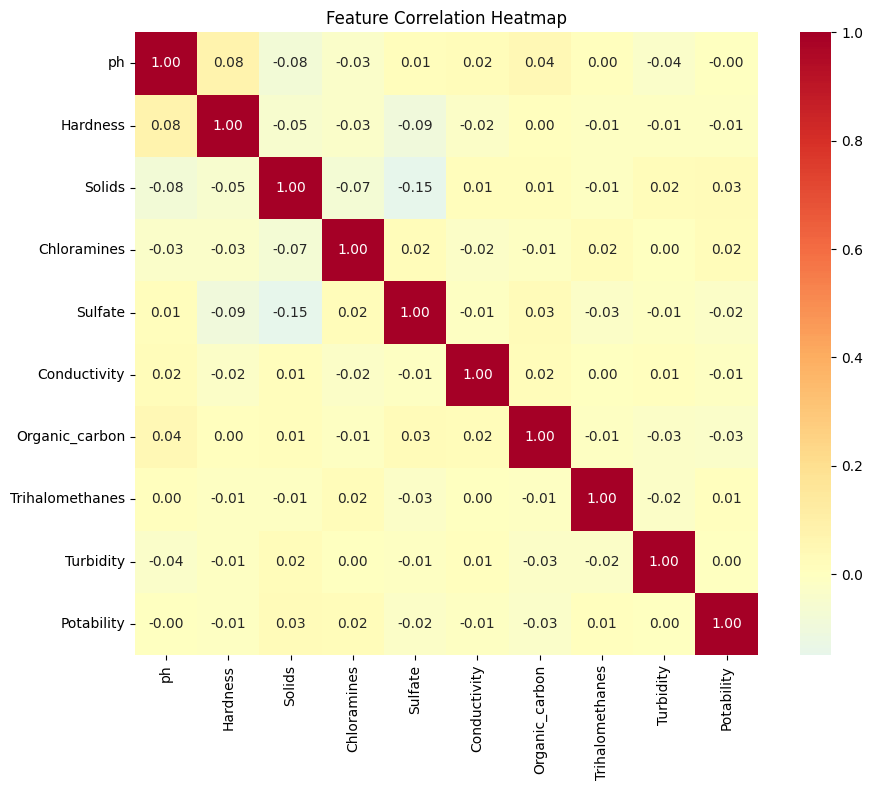

In [2]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="RdYlBu_r", center=0, square=True)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

## Pair plot (sample for speed)

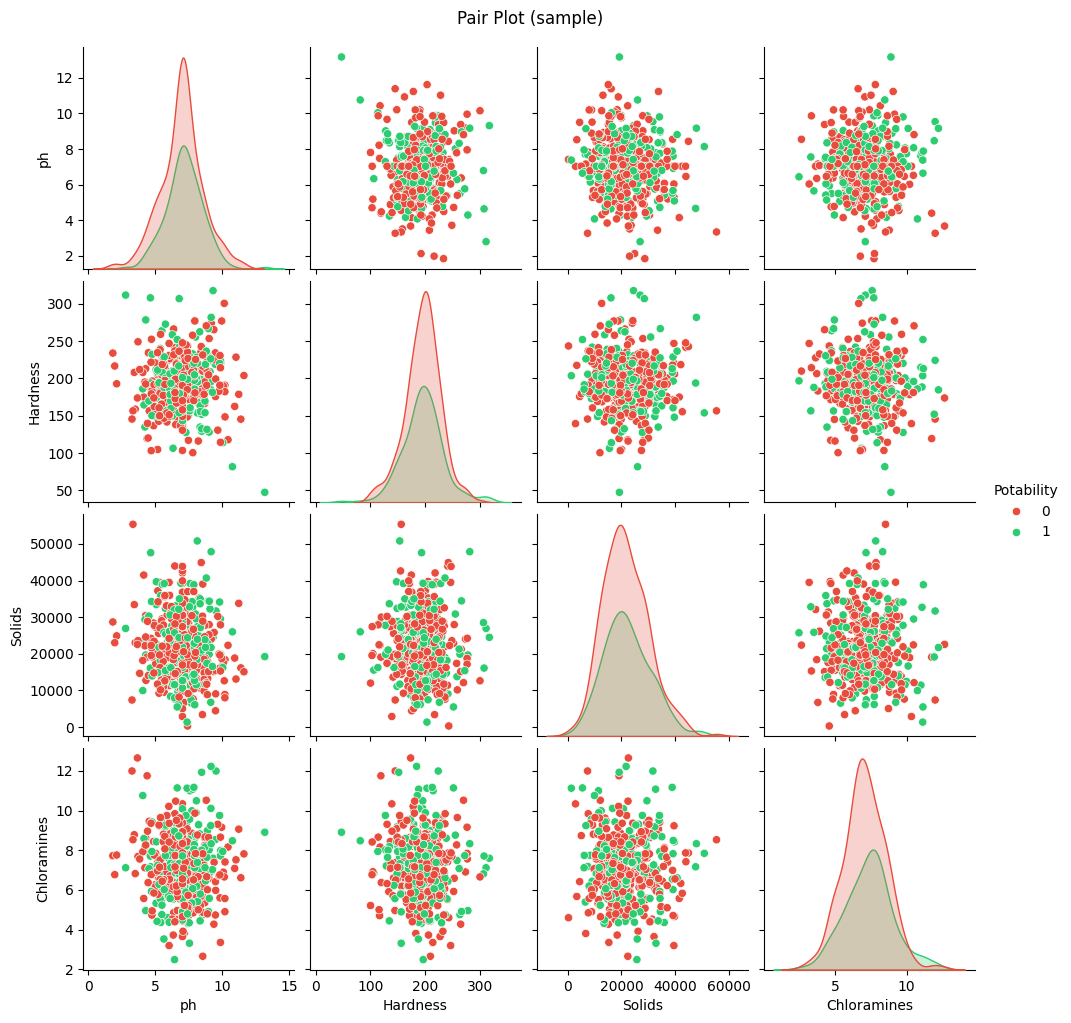

In [3]:
sample = df.sample(min(500, len(df)), random_state=42)
sns.pairplot(sample, vars=FEATURE_NAMES[:4], hue="Potability", palette={0: "#e74c3c", 1: "#2ecc71"}, diag_kind="kde")
plt.suptitle("Pair Plot (sample)", y=1.02)
plt.show()

## 3D scatter (ph, Hardness, Solids by Potability)

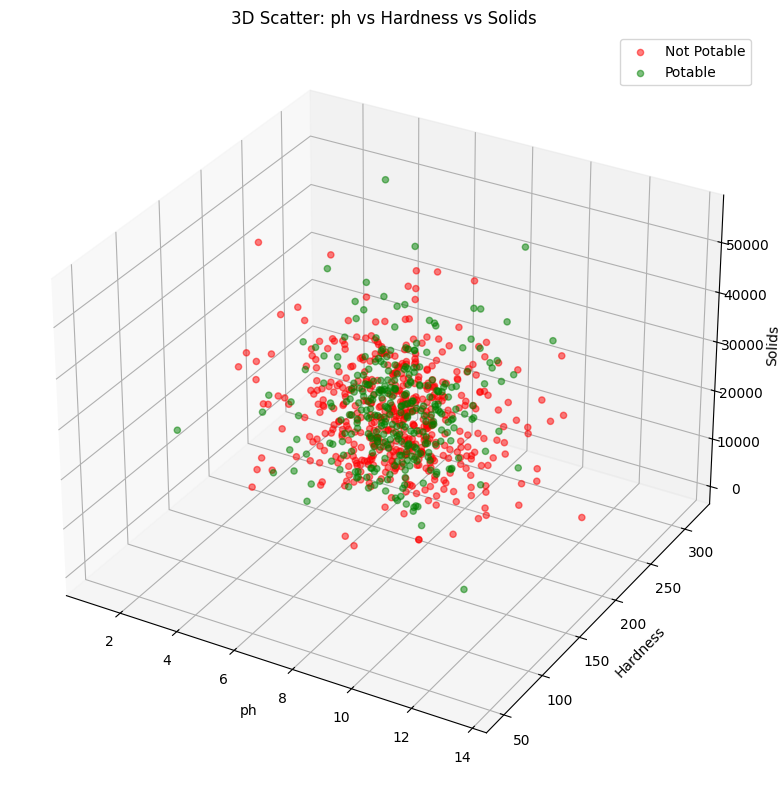

In [4]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")
s = df.sample(min(800, len(df)), random_state=42)
ax.scatter(s[s.Potability==0]["ph"], s[s.Potability==0]["Hardness"], s[s.Potability==0]["Solids"], c="red", alpha=0.5, label="Not Potable")
ax.scatter(s[s.Potability==1]["ph"], s[s.Potability==1]["Hardness"], s[s.Potability==1]["Solids"], c="green", alpha=0.5, label="Potable")
ax.set_xlabel("ph")
ax.set_ylabel("Hardness")
ax.set_zlabel("Solids")
ax.set_title("3D Scatter: ph vs Hardness vs Solids")
ax.legend()
plt.tight_layout()
plt.show()

## Distribution heatmap (features vs Potability)

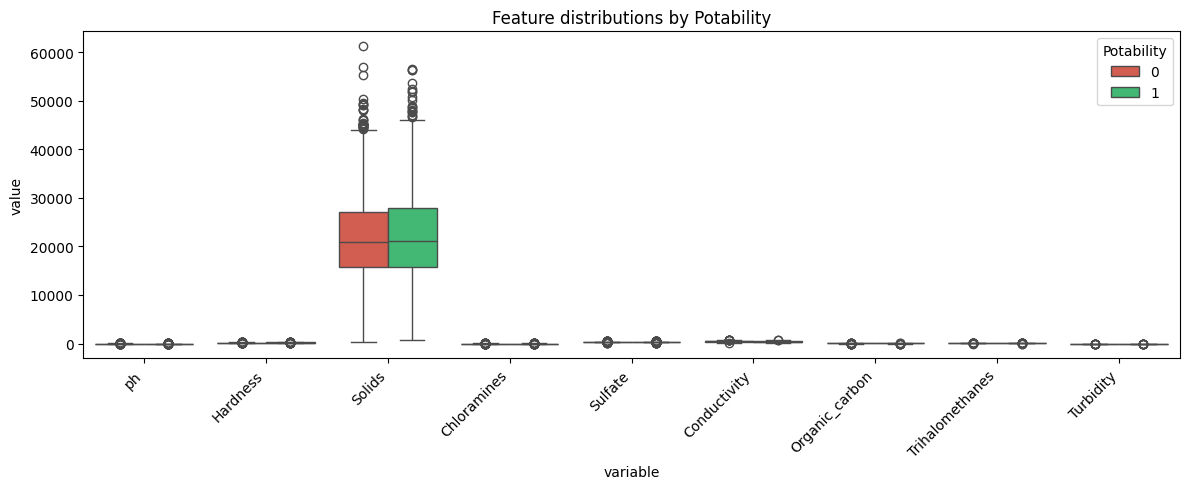

In [5]:
plt.figure(figsize=(12, 5))
df_melt = df.melt(id_vars="Potability", value_vars=FEATURE_NAMES)
sns.boxplot(data=df_melt, x="variable", y="value", hue="Potability", palette={0: "#e74c3c", 1: "#2ecc71"})
plt.xticks(rotation=45, ha="right")
plt.title("Feature distributions by Potability")
plt.tight_layout()
plt.show()

## Plotly 3D interactive

In [6]:
import plotly.express as px
s = df.sample(min(600, len(df)), random_state=42)
fig = px.scatter_3d(s, x="ph", y="Hardness", z="Solids", color="Potability", color_continuous_scale=["red", "green"])
fig.update_layout(title="Interactive 3D: ph, Hardness, Solids")
fig.show()